<a href="https://colab.research.google.com/github/Diviyah13/Machine-Learning-Portfolio-/blob/main/Advanced_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt #for visualizing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

read and display the dataset

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/Setting up dataset/wine+quality/winequality-red.csv',
    sep=';'
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Checking the dataset content

In [ ]:
df.shape

(1599, 12)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


no label encoder needed to convert string to numeric/ no dropping or concat needed to add to table

Selecting columns for clustering

In [ ]:
X = df[['alcohol', 'quality']]
X.head()

,alcohol,quality
0,9.4,5
1,9.8,5
2,9.8,5
3,9.8,6
4,9.4,5


Scale the data



In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Perform Kmeans Clustering

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    max_iter=300,
    init='k-means++', #to initialize the cluster centre
    n_init=10, #start init at 10
    random_state=0
)

kmeans.fit(X_scaled)
kmeans.labels_

array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

Plot the clustering results

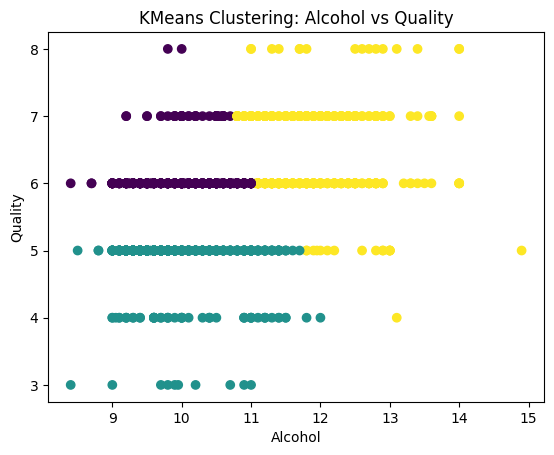

In [ ]:
plt.scatter(X['alcohol'], X['quality'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('KMeans Clustering: Alcohol vs Quality')
plt.show()

Add the cluster result to original dataframe

In [ ]:
df_cluster= df.copy()
df_cluster['cluster'] = kmeans.labels_

df_cluster.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


Define each cluster and get the descriptive statistics for each cluster



In [ ]:
df_cluster.groupby('cluster').describe()

fixed acidity                                                \
                count      mean       std  min  25%  50%  75%   max   
cluster                                                               
0               480.0  8.640000  1.837928  5.4  7.2  8.1  9.8  15.0   
1               727.0  8.155571  1.520238  5.0  7.1  7.8  8.9  15.6   
2               392.0  8.231633  1.943188  4.6  6.8  7.9  9.5  15.9   

        volatile acidity            ... alcohol       quality            \
                   count      mean  ...     75%   max   count      mean   
cluster                             ...                                   
0                  480.0  0.498312  ...    10.5  11.0   480.0  6.102083   
1                  727.0  0.590193  ...    10.2  12.0   727.0  4.900963   
2                  392.0  0.448278  ...    12.4  14.9   392.0  6.428571   

                                            
              std  min  25%  50%  75%  max  
cluster                                     
0        0.316551  6.0  6.0  6.0  6.0  8.0  
1        0.341906  3.0  5.0  5.0  5.0  5.0  
2        0.651577  4.0  6.0  6.0  7.0  8.0  

[3 rows x 96 columns]

advanced clustering” workflow
Step 1 — Select 2 variables

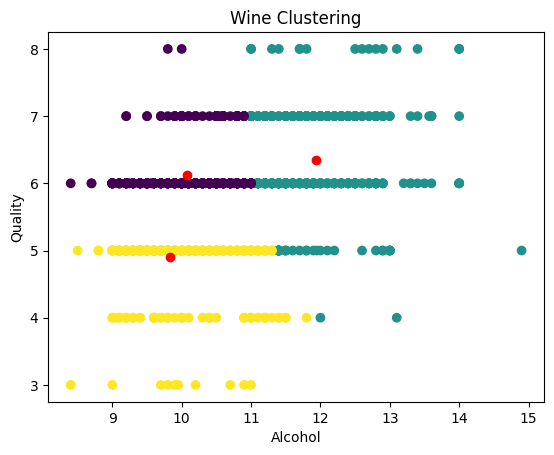

In [ ]:
X = df[['alcohol', 'quality']]

model = KMeans(n_clusters=3)

y_pred = model.fit_predict(X)

plt.scatter(
    X['alcohol'],
    X['quality'],
    c=y_pred,
    cmap='viridis'
)

centers = model.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red'
)

plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Wine Clustering')

plt.show()

In [ ]:
df_cluster = df.copy()

df_cluster['cluster'] = y_pred

df_cluster.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,2
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,2


In [ ]:
df_cluster_0 = df_cluster[df_cluster['cluster'] == 0]
df_cluster_1 = df_cluster[df_cluster['cluster'] == 1]
df_cluster_2 = df_cluster[df_cluster['cluster'] == 2]

In [ ]:
df_cluster_0.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
count,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.0
mean,8.678629,0.494597,0.278468,2.531855,0.087744,15.382056,41.195565,0.997330,3.292863,0.693145,10.080074,6.131048,0.0
std,1.856821,0.161042,0.192983,1.604738,0.043584,9.907333,23.761017,0.001606,0.142660,0.173266,0.586911,0.349551,0.0
min,5.400000,0.180000,0.000000,1.200000,0.038000,1.000000,8.000000,0.992360,2.860000,0.420000,8.400000,6.000000,0.0
25%,7.200000,0.370000,0.100000,1.900000,0.072000,8.000000,23.000000,0.996200,3.200000,0.590000,9.537500,6.000000,0.0
50%,8.200000,0.500000,0.265000,2.200000,0.079000,13.000000,36.500000,0.997200,3.305000,0.650000,10.100000,6.000000,0.0
75%,9.900000,0.600000,0.440000,2.600000,0.088250,20.250000,54.000000,0.998310,3.390000,0.760000,10.600000,6.000000,0.0
max,15.000000,1.040000,0.780000,15.400000,0.415000,72.000000,160.000000,1.003690,3.690000,1.950000,11.000000,8.000000,0.0


Higher alcohol wines

In [ ]:
df_cluster_1.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
count,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.0
mean,8.155499,0.457033,0.321023,2.568031,0.074798,14.783887,36.601023,0.995255,3.344425,0.683120,11.940367,6.347826,1.0
std,1.934469,0.164756,0.208917,1.181525,0.024218,10.088517,31.096201,0.002068,0.173951,0.128644,0.690833,0.702916,0.0
min,4.600000,0.120000,0.000000,0.900000,0.012000,3.000000,6.000000,0.990070,2.890000,0.370000,11.000000,4.000000,1.0
25%,6.700000,0.340000,0.115000,2.000000,0.061000,6.000000,17.000000,0.993900,3.225000,0.580000,11.400000,6.000000,1.0
50%,7.900000,0.420000,0.360000,2.200000,0.071000,13.000000,27.000000,0.995120,3.330000,0.670000,11.800000,6.000000,1.0
75%,9.400000,0.560000,0.470000,2.625000,0.085000,19.000000,46.000000,0.996300,3.440000,0.770000,12.400000,7.000000,1.0
max,15.900000,1.040000,0.790000,8.600000,0.230000,53.000000,289.000000,1.003200,4.010000,1.130000,14.900000,8.000000,1.0


Lower quality wines

In [ ]:
df_cluster_2.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.0
mean,8.159691,0.589838,0.238272,2.527598,0.094230,16.817416,55.558989,0.997159,3.305534,0.620056,9.828581,4.900281,2.0
std,1.493273,0.178155,0.181471,1.381542,0.056571,10.956137,36.781772,0.001494,0.148088,0.178742,0.590580,0.343556,0.0
min,5.000000,0.180000,0.000000,1.200000,0.039000,3.000000,6.000000,0.993360,2.740000,0.330000,8.400000,3.000000,2.0
25%,7.175000,0.460000,0.080000,1.900000,0.074750,8.000000,25.000000,0.996200,3.200000,0.520000,9.400000,5.000000,2.0
50%,7.800000,0.590000,0.220000,2.200000,0.082000,15.000000,47.000000,0.997000,3.300000,0.580000,9.600000,5.000000,2.0
75%,8.900000,0.680000,0.360000,2.600000,0.095000,23.000000,81.250000,0.997903,3.400000,0.660000,10.200000,5.000000,2.0
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,155.000000,1.003150,3.750000,2.000000,11.800000,5.000000,2.0


Medium alcohol and medium quality

In this exercise, the Red Wine Quality dataset was used to perform advanced clustering using the KMeans algorithm. Two variables, alcohol and quality, were selected to visualize clustering patterns among wines. The KMeans model grouped the wines into three clusters based on similarities in their characteristics.

The clustering results were visualized using a scatter plot with cluster centroids highlighted in red. Cluster labels were then added back into the original dataset to analyze the characteristics of each cluster group.

Descriptive statistics showed that each cluster represented wines with different alcohol levels and quality scores.